# Predizione del vincitore di una partita di tennis con CatBoost

## Obiettivo

Il problema e' una **classificazione binaria**:

- classe `1`: vince il giocatore A;
- classe `0`: vince il giocatore B.

L'obiettivo e' addestrare un classificatore CatBoost e verificare se riesce a
generalizzare sulle partite disputate dopo quelle usate per l'addestramento.

## Perche' CatBoost?

CatBoost e' un **metodo ensemble basato sul boosting**. Come in AdaBoost, il
boosting combina in sequenza diversi alberi decisionali: ogni nuovo albero
cerca di ridurre gli errori dell'ensemble corrente.

La previsione finale combina il contributo di tutti gli alberi. CatBoost e'
adatto perche' il dataset contiene attributi numerici e categorici, come
superficie, campo e torneo.

## Configurazione

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    brier_score_loss,
    classification_report,
    log_loss,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "scripts" / "models"
sys.path.insert(0, str(MODELS_DIR))

from train_catboost import (  # noqa: E402
    file_sha256,
    prepare_catboost_features,
    symmetrize_pair_probabilities,
)
from training_utils import chronological_holdout_split  # noqa: E402

FEATURES_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features.data"
METADATA_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features_metadata.json"
METRICS_PATH = PROJECT_ROOT / "data/interim/catboost_metrics.json"

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Caricamento del dataset

In [2]:
dataset = pd.read_csv(FEATURES_PATH)
dataset["date"] = pd.to_datetime(dataset["date"], errors="raise")

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
training_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

columns_to_show = [
    "date",
    "surface",
    "winner_rank",
    "loser_rank",
    "rank_diff",
    "win_rate_diff",
    "implied_prob_diff_avg",
    "player_a_win",
]

print("Dimensioni del dataset:", dataset.shape)
print("Esecuzione training UTC:", training_metrics["created_at_utc"])
print(
    "SHA-256 dello script di training:",
    training_metrics.get("training_script_sha256", "not recorded"),
)
print("SHA-256 dei dati di input:", training_metrics.get("input_sha256", "not recorded"))
print("SHA-256 dei metadati:", training_metrics.get("metadata_sha256", "not recorded"))

provenance_files = {
    "training_script_sha256": MODELS_DIR / "train_catboost.py",
    "input_sha256": FEATURES_PATH,
    "metadata_sha256": METADATA_PATH,
}
for metric_name, path in provenance_files.items():
    assert training_metrics.get(metric_name) == file_sha256(path), (
        f"Stale training artifact: {metric_name} does not match {path}."
    )
print("Controlli di provenienza superati.")
display(dataset[columns_to_show].head())
display(dataset["player_a_win"].value_counts().sort_index().rename("istanze").to_frame())

Dimensioni del dataset: (30952, 115)
Esecuzione training UTC: 2026-09-05T15:28:10.288840+00:00
SHA-256 dello script di training: 28ee8022ddfcb34ad9a4781737567cbd18865385f76ac9ea1d20c40ae94b2db0
SHA-256 dei dati di input: b78e589d7f0d139794a7b160f800e87721538e068739cdfbc677b3cab7e70b0f
SHA-256 dei metadati: 4e2d8079fb07521e4be8ba4246227d047a38d1eda80b5f6101b82ce970aae0ce
Controlli di provenienza superati.


,date,surface,winner_rank,loser_rank,rank_diff,win_rate_diff,implied_prob_diff_avg,player_a_win
0,2020-01-06,Hard,76.0,58.0,-18.0,NaN,-0.013926,0
1,2020-01-06,Hard,58.0,76.0,18.0,NaN,0.013926,1
2,2020-01-06,Hard,43.0,55.0,12.0,NaN,0.107462,0
3,2020-01-06,Hard,55.0,43.0,-12.0,NaN,-0.107462,1
4,2020-01-06,Hard,83.0,54.0,-29.0,NaN,-0.248736,0


,istanze
player_a_win,
0,15476
1,15476


Il dataset contiene due righe per ogni partita reale, una per ciascun
orientamento dei giocatori. In questo modo la variabile obiettivo e' bilanciata
e il modello non dipende dall'ordine originale vincitore/sconfitto.

Sono usate solo informazioni disponibili prima della partita: ranking,
risultati precedenti, rendimento sulla superficie, scontri diretti,
statistiche dei giocatori e probabilita' di mercato.

## 2. Preparazione delle feature e divisione train/test

Una divisione casuale non e' appropriata: potrebbe addestrare il modello
su partite future e valutarlo su partite precedenti.

Il 15% piu' recente delle date uniche e' quindi riservato come **test set**.
Le partite precedenti costituiscono il **training set**. I due orientamenti
della stessa partita condividono la data e restano nella stessa partizione.

In [3]:
numeric_features = tuple(metadata["numeric_features"])
categorical_features = tuple(metadata["categorical_features"])
feature_names = numeric_features + categorical_features

X = prepare_catboost_features(
    dataset.loc[:, feature_names],
    numeric_features,
    categorical_features,
)
y = dataset["player_a_win"].astype(int)

train_index, test_index = chronological_holdout_split(dataset["date"], 0.15)
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

split = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "prima data": [
            dataset.iloc[train_index]["date"].min().date(),
            dataset.iloc[test_index]["date"].min().date(),
        ],
        "ultima data": [
            dataset.iloc[train_index]["date"].max().date(),
            dataset.iloc[test_index]["date"].max().date(),
        ],
    },
    index=["addestramento", "test"],
)
display(split)

,rows,prima data,ultima data
addestramento,26472,2020-01-06,2025-08-07
test,4480,2025-08-08,2026-07-12


## 3. Baseline ingenua

Il classificatore va confrontato con una baseline semplice, che predice
sempre la classe maggioritaria.

Poiche' il dataset simmetrico e' bilanciato, l'accuratezza attesa della baseline
e' circa il 50%.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline.predict(X_test))

print(f"Accuratezza della baseline ingenua: {baseline_accuracy:.4f}")

Accuratezza della baseline ingenua: 0.5000


## 4. Ricerca degli iperparametri

I parametri sono stati scelti con `RandomizedSearchCV`. Dodici
combinazioni campionate sono state valutate con cinque fold cronologici di
cross-validation. Il test set finale non e' stato usato durante la selezione.
L'ultimo fold CV ha poi scelto il numero di alberi con early stopping.

La griglia controlla:

- `iterations`: numero di alberi nell'ensemble;
- `depth`: profondita' massima di ogni albero;
- `learning_rate`: contributo di ogni nuovo albero;
- `l2_leaf_reg`: regolarizzazione per limitare l'overfitting;
- `random_strength`: casualita' applicata alla scelta delle divisioni;
- `bagging_temperature`: intensita' del bootstrap bayesiano.

In [5]:
print("Griglia dei parametri:")
display(pd.Series(training_metrics["parameter_grid"], name="valori provati").to_frame())

cv_metric = training_metrics.get("selection_metric", "accuracy")
cv_score = training_metrics.get("best_cv_accuracy")
if cv_score is None:
    cv_score = training_metrics["best_cv_score"]
print(f"Migliore risultato di cross-validation per {cv_metric}: {cv_score:.4f}")
print("Parametri migliori:", training_metrics["best_params"])

Griglia dei parametri:


,valori provati
iterations,"[500, 1000, 1500]"
depth,"[5, 6, 7, 8]"
learning_rate,"[0.01, 0.02, 0.03, 0.05]"
l2_leaf_reg,"[3.0, 5.0, 10.0, 15.0]"
random_strength,"[0.5, 1.0, 2.0]"
bagging_temperature,"[0.0, 0.5, 1.0]"


Migliore risultato di cross-validation per neg_log_loss: -0.5867
Parametri migliori: {'random_strength': 2.0, 'learning_rate': 0.01, 'l2_leaf_reg': 15.0, 'iterations': 552, 'depth': 5, 'bagging_temperature': 1.0}


## 5. Addestramento del modello finale

In [6]:
model = CatBoostClassifier(
    **training_metrics["best_params"],
    loss_function="Logloss",
    eval_metric="Logloss",
    cat_features=categorical_features,
    random_seed=42,
    allow_writing_files=False,
    verbose=False,
    thread_count=1,
)

model.fit(X_train, y_train)
print("Addestramento completato.")

Addestramento completato.


## 6. Valutazione del classificatore

In [7]:
train_prediction = model.predict(X_train).astype(int).ravel()
raw_test_probability = model.predict_proba(X_test)[:, 1]
test_probability, test_actual_winner_probability = symmetrize_pair_probabilities(
    dataset.iloc[test_index]["match_id_internal"],
    y_test,
    raw_test_probability,
)
test_prediction = (test_probability >= 0.5).astype(int)

train_accuracy = accuracy_score(y_train, train_prediction)
test_accuracy = accuracy_score(y_test, test_prediction)
test_auc = roc_auc_score(y_test, test_probability)
test_log_loss = log_loss(y_test, test_probability)
test_brier_score = brier_score_loss(y_test, test_probability)
cv_metric = training_metrics.get("selection_metric", "accuracy")
cv_score = training_metrics.get("best_cv_accuracy")
if cv_score is None:
    cv_score = training_metrics["best_cv_score"]

market_metrics = training_metrics["market_baseline_holdout"]
results = pd.DataFrame(
    {
        "Accuratezza": [baseline_accuracy, test_accuracy, market_metrics["accuracy"]],
        "ROC AUC": [np.nan, test_auc, market_metrics["roc_auc"]],
        "Log loss": [np.nan, test_log_loss, market_metrics["log_loss"]],
        "Brier score": [np.nan, test_brier_score, market_metrics["brier_score"]],
    },
    index=["Baseline ingenua", "Holdout CatBoost", "Baseline di mercato"],
)
display(results)
print(f"Accuratezza training: {train_accuracy:.4f}")
print(f"Punteggio di cross-validation {cv_metric}: {cv_score:.4f}")

,Accuratezza,ROC AUC,Log loss,Brier score
Baseline ingenua,0.500000,NaN,NaN,NaN
Holdout CatBoost,0.691518,0.757277,0.582823,0.200061
Baseline di mercato,0.691518,0.757795,0.581768,0.199607


Accuratezza training: 0.6849
Punteggio di cross-validation neg_log_loss: -0.5867


### Matrice di confusione

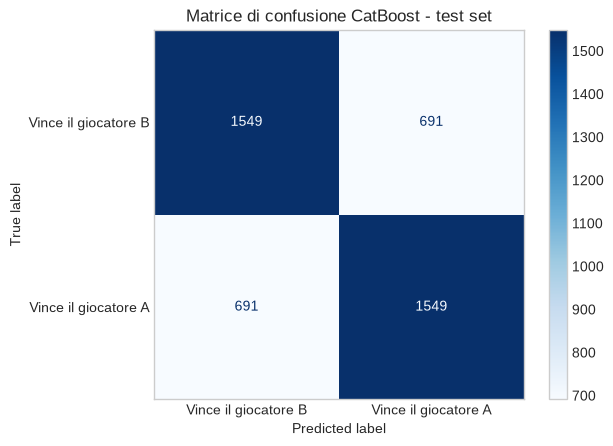

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["Vince il giocatore B", "Vince il giocatore A"],
    cmap="Blues",
)
plt.title("Matrice di confusione CatBoost - test set")
plt.grid(False)
plt.show()

### Precisione, richiamo e F1-score

In [9]:
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=["Vince il giocatore B", "Vince il giocatore A"],
        digits=4,
    )
)

                      precision    recall  f1-score   support

Vince il giocatore B     0.6915    0.6915    0.6915      2240
Vince il giocatore A     0.6915    0.6915    0.6915      2240

            accuracy                         0.6915      4480
           macro avg     0.6915    0.6915    0.6915      4480
        weighted avg     0.6915    0.6915    0.6915      4480



### Curva ROC

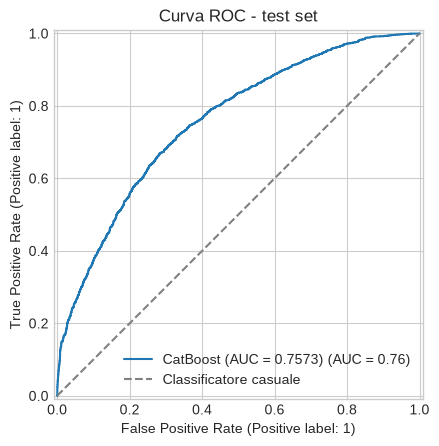

In [10]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
    name=f"CatBoost (AUC = {test_auc:.4f})",
)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Classificatore casuale")
plt.title("Curva ROC - test set")
plt.legend()
plt.show()

## 7. Importanza delle feature

I modelli basati su alberi espongono un punteggio di importanza delle
feature, che indica quanto ciascuna contribuisce alle decisioni dell'ensemble.
L'importanza aiuta a interpretare il modello, ma non dimostra un rapporto
causale.

,importance
loser_implied_prob_avg,16.219213
implied_prob_diff_avg,14.496559
winner_market_prob_normalized,13.918622
loser_market_prob_normalized,13.203903
normalized_market_prob_diff,12.710898
winner_implied_prob_avg,12.628452
market_overround_avg,1.907254
points_diff,0.824996
smoothed_surface_diff,0.785188
log_points_diff,0.772255


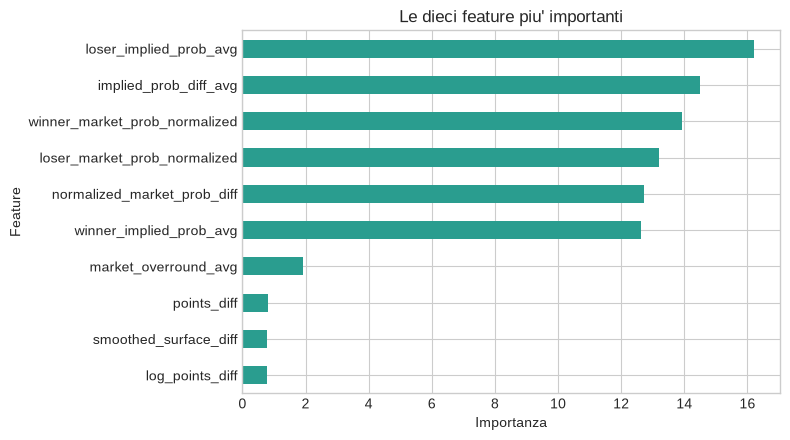

In [11]:
feature_importance = (
    pd.Series(
        np.asarray(model.feature_importances_, dtype=float),
        index=feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
)

display(feature_importance.head(10).to_frame())

ax = feature_importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 4.5),
    color="#2a9d8f",
)
ax.set_title("Le dieci feature piu' importanti")
ax.set_xlabel("Importanza")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 8. Analisi delle partite piu' facili e piu' difficili

Le righe sono abbinate tramite `match_id_internal`, quindi ogni partita
reale viene contata una sola volta. La confidenza assegnata al vincitore reale
e' mediata tra i due orientamenti. Le previsioni piu' corrette assegnano la
probabilita' maggiore al vincitore reale; quelle piu' errate la minore.

In [12]:
holdout = dataset.iloc[test_index].copy()
holdout["actual_winner_probability"] = test_actual_winner_probability

pair_sizes = holdout.groupby("match_id_internal").size()
assert pair_sizes.eq(2).all(), "Ogni partita di holdout deve avere due orientamenti."

match_diagnostics = (
    holdout.loc[holdout["player_a_win"].eq(1)]
    .set_index("match_id_internal")
)
match_diagnostics["correct"] = (
    match_diagnostics["actual_winner_probability"] >= 0.5
)
match_diagnostics["predicted_winner"] = np.where(
    match_diagnostics["correct"],
    match_diagnostics["winner_name"],
    match_diagnostics["loser_name"],
)

assert len(match_diagnostics) * 2 == len(holdout)
print(f"Partite reali nell'holdout: {len(match_diagnostics):,}")
print(f"Accuratezza per partita: {match_diagnostics['correct'].mean():.4f}")

Partite reali nell'holdout: 2,240
Accuratezza per partita: 0.6915


### Previsioni corrette con maggiore confidenza

In [13]:
instance_columns = [
    "date",
    "winner_name",
    "loser_name",
    "predicted_winner",
    "surface",
    "round",
    "series",
    "winner_rank",
    "loser_rank",
    "normalized_market_prob_diff",
    "actual_winner_probability",
]

most_correct = match_diagnostics.nlargest(
    10, "actual_winner_probability"
)[instance_columns]
display(most_correct)

,date,winner_name,loser_name,predicted_winner,surface,round,series,winner_rank,loser_rank,normalized_market_prob_diff,actual_winner_probability
match_id_internal,,,,,,,,,,,
15120,2026-05-26,Sinner J.,Tabur C.,Sinner J.,Clay,1st Round,GrandSlam,1.0,171.0,0.951501,0.929540
14128,2026-01-22,Sinner J.,Duckworth J.,Sinner J.,Hard,2nd Round,GrandSlam,2.0,88.0,0.912781,0.928312
14041,2026-01-18,Alcaraz C.,Walton A.,Alcaraz C.,Hard,1st Round,GrandSlam,1.0,81.0,0.919426,0.928157
13415,2025-08-26,Sinner J.,Kopriva V.,Sinner J.,Hard,1st Round,GrandSlam,1.0,89.0,0.928823,0.928005
14892,2026-04-26,Sinner J.,Moller E.,Sinner J.,Clay,3rd Round,Masters1000,1.0,169.0,0.900394,0.925821
15464,2026-07-05,Sinner J.,Mochizuki S.,Sinner J.,Grass,4th Round,GrandSlam,1.0,151.0,0.884419,0.925629
14147,2026-01-24,Sinner J.,Spizzirri E.,Sinner J.,Hard,3rd Round,GrandSlam,2.0,85.0,0.940867,0.925579
14154,2026-01-26,Sinner J.,Darderi L.,Sinner J.,Hard,4th Round,GrandSlam,2.0,25.0,0.880702,0.925164
14975,2026-05-09,Sinner J.,Ofner S.,Sinner J.,Clay,2nd Round,Masters1000,1.0,82.0,0.900737,0.925052


### Previsioni errate con maggiore confidenza

In [14]:
most_wrong = match_diagnostics.nsmallest(
    10, "actual_winner_probability"
)[instance_columns]
display(most_wrong)

,date,winner_name,loser_name,predicted_winner,surface,round,series,winner_rank,loser_rank,normalized_market_prob_diff,actual_winner_probability
match_id_internal,,,,,,,,,,,
15145,2026-05-28,Cerundolo J.M.,Sinner J.,Sinner J.,Clay,2nd Round,GrandSlam,56.0,1.0,-0.917585,0.071256
13833,2025-10-28,Norrie C.,Alcaraz C.,Alcaraz C.,Hard,2nd Round,Masters1000,31.0,1.0,-0.818809,0.086928
14638,2026-03-30,Bennani K.,Halys Q.,Halys Q.,Clay,1st Round,ATP250,731.0,90.0,-0.805014,0.093940
15126,2026-05-26,Walton A.,Medvedev D.,Medvedev D.,Clay,1st Round,GrandSlam,97.0,8.0,-0.845577,0.098410
14374,2026-02-24,Kypson P.,De Minaur A.,De Minaur A.,Hard,1st Round,ATP500,103.0,6.0,-0.785208,0.102293
14637,2026-03-30,Baadi T.,Vukic A.,Vukic A.,Clay,1st Round,ATP250,587.0,84.0,-0.768398,0.106545
14159,2026-01-30,Djokovic N.,Sinner J.,Sinner J.,Hard,Semifinals,GrandSlam,4.0,2.0,-0.779381,0.111958
14337,2026-02-19,Mensik J.,Sinner J.,Sinner J.,Hard,Quarterfinals,ATP500,16.0,2.0,-0.778243,0.116735
15169,2026-05-30,Svajda Z.,Cerundolo F.,Cerundolo F.,Clay,3rd Round,GrandSlam,85.0,26.0,-0.756818,0.125347


### Distribuzioni numeriche: previsioni corrette ed errate

Per ogni feature numerica, la tabella confronta mediane, tassi di valori
mancanti e differenza tra le medie espressa in deviazioni standard complessive.
Le differenze assolute maggiori mostrano dove gli errori occupano una parte
diversa della distribuzione, senza implicare causalita'.

,feature,wrong_minus_correct_sd,correct_median,wrong_median,correct_missing_rate,wrong_missing_rate,absolute_shift,missing_rate_delta
15,winner_implied_prob_avg,-1.766895,0.719424,0.404858,0.000000,0.000000,1.766895,0.000000
17,implied_prob_diff_avg,-1.763825,0.378128,-0.250369,0.000000,0.000000,1.763825,0.000000
18,winner_market_prob_normalized,-1.760581,0.677570,0.381546,0.000000,0.000000,1.760581,0.000000
19,loser_market_prob_normalized,1.760581,0.322430,0.618454,0.000000,0.000000,1.760581,0.000000
20,normalized_market_prob_diff,-1.760581,0.355140,-0.236908,0.000000,0.000000,1.760581,0.000000
16,loser_implied_prob_avg,1.760446,0.341297,0.653595,0.000000,0.000000,1.760446,0.000000
68,elo_diff,-1.301973,123.102005,-83.631605,0.000000,0.000000,1.301973,0.000000
22,log_rank_diff,-1.268973,0.996978,-0.619039,0.000646,0.002894,1.268973,0.002249
71,surface_elo_diff,-1.240634,97.581008,-68.259373,0.000000,0.000000,1.240634,0.000000
24,log_points_diff,-1.236233,0.806407,-0.460558,0.000646,0.002894,1.236233,0.002249


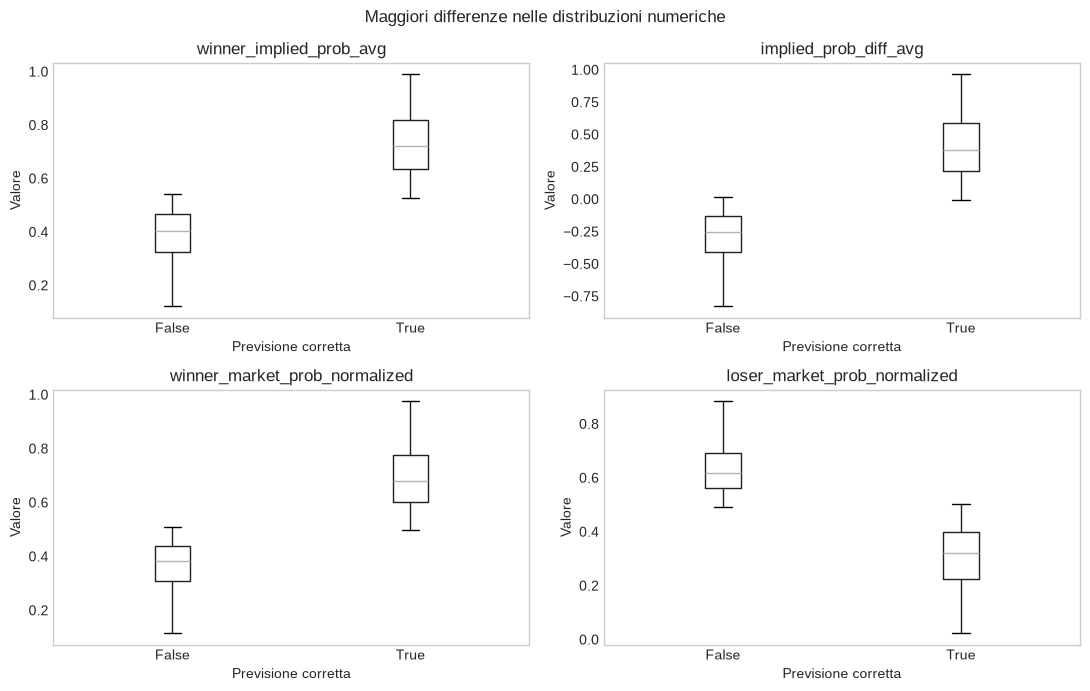

In [15]:
distribution_rows = []
for feature in numeric_features:
    correct_values = pd.to_numeric(
        match_diagnostics.loc[match_diagnostics["correct"], feature],
        errors="coerce",
    )
    wrong_values = pd.to_numeric(
        match_diagnostics.loc[~match_diagnostics["correct"], feature],
        errors="coerce",
    )
    overall_std = pd.to_numeric(
        match_diagnostics[feature], errors="coerce"
    ).std()
    standardized_shift = (
        (wrong_values.mean() - correct_values.mean()) / overall_std
        if overall_std > 0
        else np.nan
    )
    distribution_rows.append(
        {
            "feature": feature,
            "wrong_minus_correct_sd": standardized_shift,
            "correct_median": correct_values.median(),
            "wrong_median": wrong_values.median(),
            "correct_missing_rate": correct_values.isna().mean(),
            "wrong_missing_rate": wrong_values.isna().mean(),
        }
    )

numeric_distribution_shift = (
    pd.DataFrame(distribution_rows)
    .assign(
        absolute_shift=lambda frame: frame["wrong_minus_correct_sd"].abs(),
        missing_rate_delta=lambda frame: (
            frame["wrong_missing_rate"] - frame["correct_missing_rate"]
        ),
    )
    .sort_values("absolute_shift", ascending=False)
)
display(numeric_distribution_shift.head(15))

top_shift_features = numeric_distribution_shift.head(4)["feature"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for feature, axis in zip(top_shift_features, axes.ravel(), strict=True):
    match_diagnostics.boxplot(
        column=feature,
        by="correct",
        ax=axis,
        showfliers=False,
        grid=False,
    )
    axis.set_title(feature)
    axis.set_xlabel("Previsione corretta")
    axis.set_ylabel("Valore")
plt.suptitle("Maggiori differenze nelle distribuzioni numeriche")
plt.tight_layout()
plt.show()

### Distribuzioni delle feature categoriche

In [16]:
overall_error_rate = 1 - match_diagnostics["correct"].mean()
categorical_rows = []
for feature in categorical_features:
    grouped = match_diagnostics.groupby(feature, dropna=False)["correct"].agg(
        matches="size",
        error_rate=lambda values: 1 - values.mean(),
    )
    grouped = grouped.loc[grouped["matches"] >= 20].reset_index()
    grouped.insert(0, "feature", feature)
    categorical_rows.append(grouped.rename(columns={feature: "value"}))

categorical_error_rates = pd.concat(categorical_rows, ignore_index=True)
categorical_error_rates["difference_from_overall"] = (
    categorical_error_rates["error_rate"] - overall_error_rate
)
categorical_error_rates["absolute_difference"] = categorical_error_rates[
    "difference_from_overall"
].abs()
categorical_error_rates = categorical_error_rates.sort_values(
    "absolute_difference", ascending=False
)
display(categorical_error_rates.head(15))

,feature,value,matches,error_rate,difference_from_overall,absolute_difference
31,tournament_bucket,Grand Prix Hassan II,25,0.480000,0.171518,0.171518
88,location_bucket,Marrakech,25,0.480000,0.171518,0.171518
24,tournament_bucket,Dallas Open,31,0.161290,-0.147192,0.147192
45,tournament_bucket,Qatar Exxon Mobil Open,31,0.161290,-0.147192,0.147192
75,location_bucket,Doha,31,0.161290,-0.147192,0.147192
73,location_bucket,Dallas,31,0.161290,-0.147192,0.147192
19,tournament_bucket,Barcelona Open,29,0.172414,-0.136068,0.136068
65,location_bucket,Barcelona,29,0.172414,-0.136068,0.136068
60,location_bucket,'s-Hertogenbosch,27,0.444444,0.135962,0.135962
48,tournament_bucket,Rosmalen Grass Court Championships,27,0.444444,0.135962,0.135962


### Quali peculiarita' emergono?

In [17]:
odds_importance_share = feature_importance.loc[
    [
        "winner_implied_prob_avg",
        "loser_implied_prob_avg",
        "implied_prob_diff_avg",
        "winner_market_prob_normalized",
        "loser_market_prob_normalized",
        "normalized_market_prob_diff",
    ]
].sum() / feature_importance.sum()
wrong_matches = match_diagnostics.loc[~match_diagnostics["correct"]]
upset_share = wrong_matches["normalized_market_prob_diff"].lt(0).mean()
largest_missing_gap = numeric_distribution_shift["missing_rate_delta"].abs().max()

print(f"Importanza assegnata alle sei feature delle quote: {odds_importance_share:.1%}")
print(f"Errori in cui il vincitore reale era sfavorito dal mercato: {upset_share:.1%}")
print(f"Massima differenza nel tasso di valori mancanti: {largest_missing_gap:.1%}")
print(
    "Interpretazione: gli errori sono soprattutto vere sorprese. Ranking, Elo, forma e "
    "differenze nelle probabilita' di mercato cambiano segno nel gruppo degli errori. "
    "Non emerge un'anomalia altrettanto grande nei dati mancanti. Le differenze tra "
    "categorie vanno interpretate con cautela perche' molti gruppi sono piccoli."
)

Importanza assegnata alle sei feature delle quote: 83.2%
Errori in cui il vincitore reale era sfavorito dal mercato: 99.3%
Massima differenza nel tasso di valori mancanti: 3.8%
Interpretazione: gli errori sono soprattutto vere sorprese. Ranking, Elo, forma e differenze nelle probabilita' di mercato cambiano segno nel gruppo degli errori. Non emerge un'anomalia altrettanto grande nei dati mancanti. Le differenze tra categorie vanno interpretate con cautela perche' molti gruppi sono piccoli.


## Conclusioni

- La baseline ingenua ottiene circa il **50% di accuratezza** perche' le classi sono
  bilanciate.
- Il punteggio di selezione di CatBoost e' **neg_log_loss -0.5867** e la sua accuratezza sull'holdout e'
  **0.6915**.
- Il modello migliora chiaramente rispetto alla baseline ingenua.
- Pareggia la baseline di mercato sull'accuratezza, ma il mercato resta leggermente
  migliore per ROC AUC, log loss e Brier score. Questa esecuzione quindi non
  dimostra un vantaggio predittivo rispetto al mercato delle scommesse.
- Le probabilita' implicite di mercato sono le feature piu' importanti. Quindi
  parte del potere predittivo deriva da informazioni gia' contenute nelle
  quote delle scommesse.
- Gli errori piu' sicuri sono soprattutto sorprese in cui ranking, Elo, forma
  e quote favorivano tutti il giocatore poi sconfitto. Non emerge un'anomalia
  altrettanto grande nei valori mancanti tra previsioni corrette ed errate.
- La differenza tra accuratezza di training e test va monitorata: un punteggio
  di training molto maggiore indicherebbe overfitting.

Il test set finale e' usato una sola volta per la valutazione. Ogni modifica futura a
feature o parametri CatBoost deve essere scelta usando i fold di
cross-validation del training, non questo risultato di test.